In [2]:
#importing all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import pickle
import warnings
warnings.filterwarnings('ignore')


In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Machine Learning/Datasets/atm_cash_management_dataset.csv') #read the datasets
data.head()


,ATM_ID,Date,Day_of_Week,Time_of_Day,Total_Withdrawals,Total_Deposits,Location_Type,Holiday_Flag,Special_Event_Flag,Previous_Day_Cash_Level,Weather_Condition,Nearby_Competitor_ATMs,Cash_Demand_Next_Day
0,ATM_0041,2022-04-25,Monday,Morning,57450,9308,Standalone,0,0,112953,Rainy,5,44165
1,ATM_0007,2023-11-24,Friday,Morning,72845,17896,Supermarket,0,0,115348,Clear,0,41249
2,ATM_0014,2022-08-27,Saturday,Morning,42957,12712,Supermarket,0,0,90731,Cloudy,1,29901
3,ATM_0029,2023-08-27,Sunday,Evening,43014,1375,Mall,0,0,88754,Rainy,5,44155
4,ATM_0028,2022-12-15,Thursday,Evening,36379,2938,Bank Branch,0,0,129312,Snowy,0,29784


In [5]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5658 entries, 0 to 5657
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   ATM_ID                   5658 non-null   object
 1   Date                     5658 non-null   object
 2   Day_of_Week              5658 non-null   object
 3   Time_of_Day              5658 non-null   object
 4   Total_Withdrawals        5658 non-null   int64 
 5   Total_Deposits           5658 non-null   int64 
 6   Location_Type            5658 non-null   object
 7   Holiday_Flag             5658 non-null   int64 
 8   Special_Event_Flag       5658 non-null   int64 
 9   Previous_Day_Cash_Level  5658 non-null   int64 
 10  Weather_Condition        5658 non-null   object
 11  Nearby_Competitor_ATMs   5658 non-null   int64 
 12  Cash_Demand_Next_Day     5658 non-null   int64 
dtypes: int64(7), object(6)
memory usage: 574.8+ KB


In [6]:
data.isnull().sum()  # find if any null values are present


,0
ATM_ID,0
Date,0
Day_of_Week,0
Time_of_Day,0
Total_Withdrawals,0
Total_Deposits,0
Location_Type,0
Holiday_Flag,0
Special_Event_Flag,0
Previous_Day_Cash_Level,0


In [7]:
data[data.duplicated()]# To find duplicates


,ATM_ID,Date,Day_of_Week,Time_of_Day,Total_Withdrawals,Total_Deposits,Location_Type,Holiday_Flag,Special_Event_Flag,Previous_Day_Cash_Level,Weather_Condition,Nearby_Competitor_ATMs,Cash_Demand_Next_Day


In [8]:
data.describe() # Description of data


,Total_Withdrawals,Total_Deposits,Holiday_Flag,Special_Event_Flag,Previous_Day_Cash_Level,Nearby_Competitor_ATMs,Cash_Demand_Next_Day
count,5658.000000,5658.000000,5658.000000,5658.000000,5658.000000,5658.000000,5658.000000
mean,49808.106928,10129.078473,0.022093,0.096501,100283.994698,2.477731,43085.207494
std,14903.539241,4878.853583,0.146998,0.295303,20122.365608,1.719487,16797.100086
min,1380.000000,0.000000,0.000000,0.000000,23266.000000,0.000000,0.000000
25%,39469.250000,6765.000000,0.000000,0.000000,86533.500000,1.000000,31558.750000
50%,50039.000000,10048.000000,0.000000,0.000000,100276.500000,2.000000,42589.500000
75%,60132.500000,13430.000000,0.000000,0.000000,113956.500000,4.000000,53831.000000
max,107790.000000,32395.000000,1.000000,1.000000,172227.000000,5.000000,114724.000000


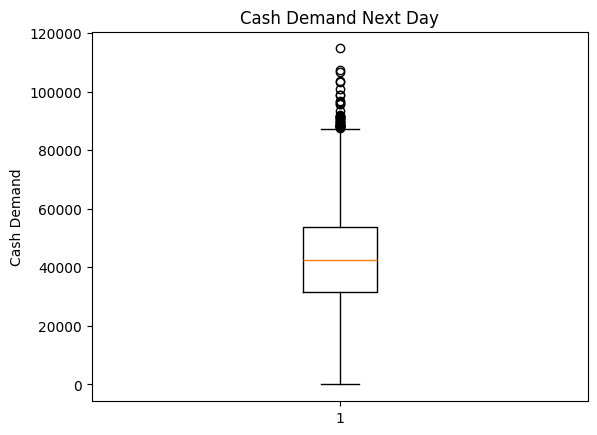

Outliers: 36


In [29]:
# Boxplot
plt.boxplot(data["Cash_Demand_Next_Day"])
plt.title("Cash Demand Next Day")
plt.ylabel("Cash Demand")
plt.show()

# Find outliers using IQR(Interquartile Range)
Q1 = data["Cash_Demand_Next_Day"].quantile(0.25)
Median = data["Cash_Demand_Next_Day"].quantile(0.50)
Q3 = data["Cash_Demand_Next_Day"].quantile(0.75)
IQR = Q3 - Q1

outliers = data[
    (data["Cash_Demand_Next_Day"] < Q1 - 1.5 * IQR) |
    (data["Cash_Demand_Next_Day"] > Q3 + 1.5 * IQR)
]

print("Outliers:", len(outliers))

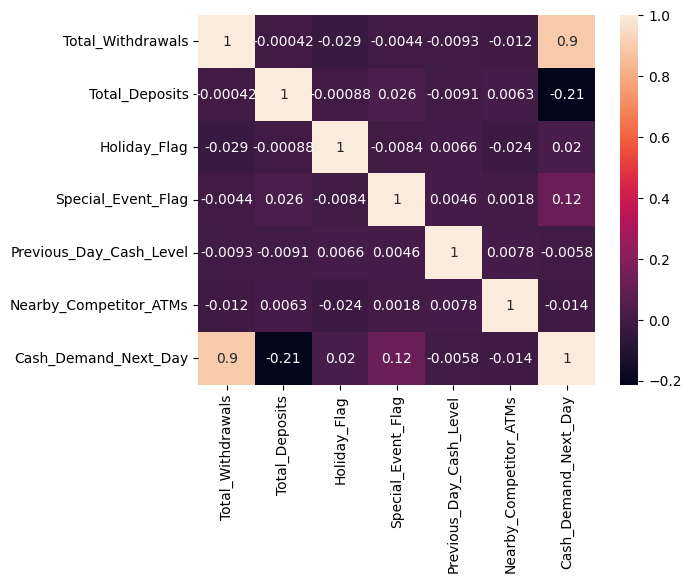

In [27]:
import seaborn as sns
sns.heatmap(data.corr(numeric_only=True), annot=True)
plt.show()

In [31]:
cat_cols = ['Day_of_Week', 'Time_of_Day', 'Location_Type', 'Weather_Condition'] #using one hot encoder values are essentially True/False
data_encoded = pd.get_dummies(data, columns=cat_cols, drop_first=True)
data_encoded.head()


,ATM_ID,Date,Total_Withdrawals,Total_Deposits,Holiday_Flag,Special_Event_Flag,Previous_Day_Cash_Level,Nearby_Competitor_ATMs,Cash_Demand_Next_Day,Day_of_Week_Monday,...,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Location_Type_Gas Station,Location_Type_Mall,Location_Type_Standalone,Location_Type_Supermarket,Weather_Condition_Cloudy,Weather_Condition_Rainy,Weather_Condition_Snowy
0,ATM_0041,2022-04-25,57450,9308,0,0,112953,5,44165,True,...,False,True,False,False,False,True,False,False,True,False
1,ATM_0007,2023-11-24,72845,17896,0,0,115348,0,41249,False,...,False,True,False,False,False,False,True,False,False,False
2,ATM_0014,2022-08-27,42957,12712,0,0,90731,1,29901,False,...,False,True,False,False,False,False,True,True,False,False
3,ATM_0029,2023-08-27,43014,1375,0,0,88754,5,44155,False,...,True,False,False,False,True,False,False,False,True,False
4,ATM_0028,2022-12-15,36379,2938,0,0,129312,0,29784,False,...,True,False,False,False,False,False,False,False,False,True


In [14]:
# Remove unnecessary columns
X = data_encoded.drop(columns=["ATM_ID", "Date", "Cash_Demand_Next_Day"])
# Target column
y = data_encoded["Cash_Demand_Next_Day"]
# Display first 5 rows
X.head()


,Total_Withdrawals,Total_Deposits,Holiday_Flag,Special_Event_Flag,Previous_Day_Cash_Level,Nearby_Competitor_ATMs,Day_of_Week_Monday,Day_of_Week_Saturday,Day_of_Week_Sunday,Day_of_Week_Thursday,...,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Location_Type_Gas Station,Location_Type_Mall,Location_Type_Standalone,Location_Type_Supermarket,Weather_Condition_Cloudy,Weather_Condition_Rainy,Weather_Condition_Snowy
0,57450,9308,0,0,112953,5,True,False,False,False,...,False,True,False,False,False,True,False,False,True,False
1,72845,17896,0,0,115348,0,False,False,False,False,...,False,True,False,False,False,False,True,False,False,False
2,42957,12712,0,0,90731,1,False,True,False,False,...,False,True,False,False,False,False,True,True,False,False
3,43014,1375,0,0,88754,5,False,False,True,False,...,True,False,False,False,True,False,False,False,True,False
4,36379,2938,0,0,129312,0,False,False,False,True,...,True,False,False,False,False,False,False,False,False,True


In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # train and test the data

scaler = StandardScaler() # StandardScaler scales the features so they have a mean of 0 and a standard deviation of 1.
X_train_scaled = scaler.fit_transform(X_train)  #fit-Learns the mean and standard deviation from the training data.Transform-Uses those values to scale the data.
X_test_scaled = scaler.transform(X_test)


In [16]:
model = LinearRegression()
model.fit(X_train_scaled, y_train) #fit the model

pred_train = model.predict(X_train_scaled)
pred_test = model.predict(X_test_scaled)

metrics = {
    "Train R2": r2_score(y_train, pred_train),
    "Test R2": r2_score(y_test, pred_test),
    "Test MAE": mean_absolute_error(y_test, pred_test),
    "Test RMSE": mean_squared_error(y_test, pred_test) ** 0.5,
    "Test MAPE %": mean_absolute_percentage_error(y_test, pred_test) * 100,
}
pd.DataFrame([metrics])
# Accuracy of the given data

,Train R2,Test R2,Test MAE,Test RMSE,Test MAPE %
0,0.863693,0.870465,5043.14583,6112.522797,4.121486e+18


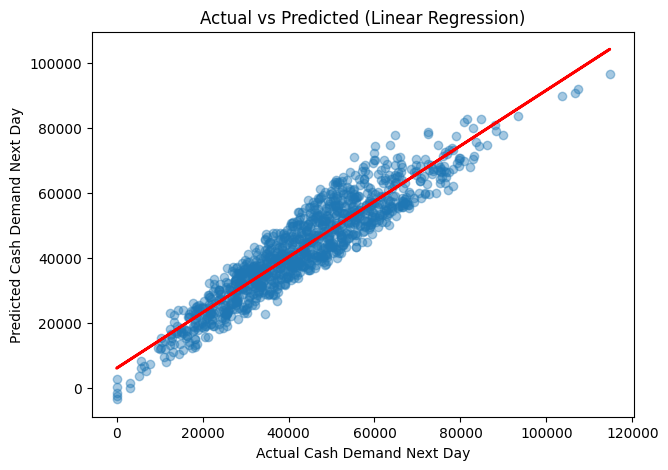

Slope: 0.8563872497108348          Intercept: 5968.941218273819


In [17]:
y_pred = pred_test
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, alpha=0.4)
m, c = np.polyfit(y_test, y_pred, 1)
plt.plot(y_test, m * y_test + c, 'r', linewidth=2)
plt.xlabel("Actual Cash Demand Next Day")
plt.ylabel("Predicted Cash Demand Next Day")
plt.title("Actual vs Predicted (Linear Regression)")
plt.show()

print("Slope:", m, "         Intercept:", c)


In [19]:
importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": model.coef_,
}).sort_values("Coefficient", key=abs, ascending=False)
importance_df


,Feature,Coefficient
0,Total_Withdrawals,14993.829146
1,Total_Deposits,-3628.594576
3,Special_Event_Flag,2166.369410
2,Holiday_Flag,825.223060
16,Location_Type_Mall,214.410247
19,Weather_Condition_Cloudy,212.322062
21,Weather_Condition_Snowy,190.874449
20,Weather_Condition_Rainy,174.125766
13,Time_of_Day_Morning,-135.578103
10,Day_of_Week_Tuesday,-126.171761


In [20]:
with open('atm_model.pkl', 'wb') as f:
    pickle.dump({
        'model': model,
        'scaler': scaler,
        'feature_cols': feature_cols
    }, f)

print("Saved: atm_model.pkl")


Saved: atm_model.pkl


In [21]:
with open('atm_model.pkl', 'rb') as f:
    saved = pickle.load(f)
new_row = {
    "Total_Withdrawals": 57450,
    "Total_Deposits": 9308,
    "Holiday_Flag": 0,
    "Special_Event_Flag": 0,
    "Previous_Day_Cash_Level": 112953,
    "Nearby_Competitor_ATMs": 5,
    "Day_of_Week": "Monday",
    "Time_of_Day": "Morning",
    "Location_Type": "Standalone",
    "Weather_Condition": "Rainy",
}
new_sample = pd.DataFrame([new_row])
new_sample = pd.get_dummies(new_sample, columns=['Day_of_Week', 'Time_of_Day', 'Location_Type', 'Weather_Condition'])
new_sample = new_sample.reindex(columns=saved['feature_cols'], fill_value=0)
new_sample_scaled = saved['scaler'].transform(new_sample)
prediction = saved['model'].predict(new_sample_scaled)
print("Predicted Cash Demand Next Day:", prediction[0])


Predicted Cash Demand Next Day: 50288.77941369336
